In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

import os # 파일 시스템 경로 작업을 위해 (CSV 파일 로드 시 유용)

# 데이터 분할 및 모델 선택 도구
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,cross_validate

# 전처리 도구
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 머신러닝 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

# 모델 평가 지표
from sklearn.metrics import classification_report, accuracy_score, \
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, \
        r2_score

# 선형회귀 모델 작성, 예측 , 평가
- LinearRegression
- RandomForestRegressor

In [3]:
df = pd.read_csv('./data/premium.csv')
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [4]:
pd.isnull(df).sum()

age         0
sex         0
bmi         5
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
bmi_mean = df['bmi'].mean()
df['bmi'] = df['bmi'].fillna(bmi_mean)

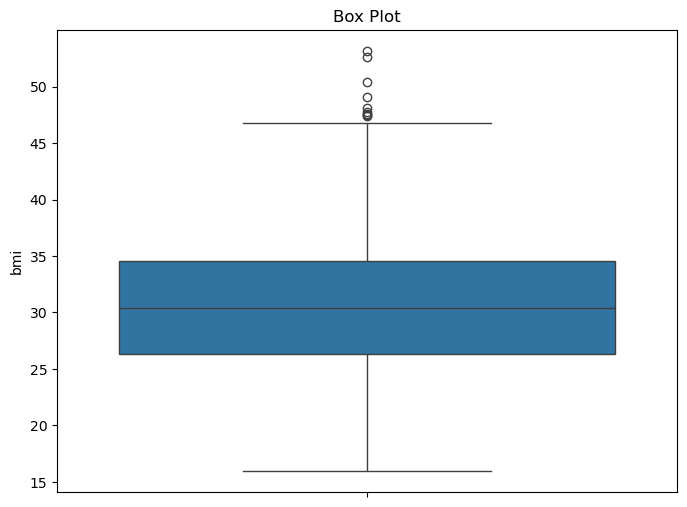

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['bmi'])
plt.title('Box Plot')
plt.show()


Q1 (25th percentile): 26.32
Q3 (75th percentile): 34.60
IQR: 8.29
하한 (Lower Bound): 13.89
상한 (Upper Bound): 47.03

원본 데이터 행 수: 1338
이상치 제거 후 데이터 행 수: 1329

이상치 제거 후 BMI 데이터 (head):
0    27.900
1    33.770
2    33.000
3    22.705
4    28.880
Name: bmi, dtype: float64


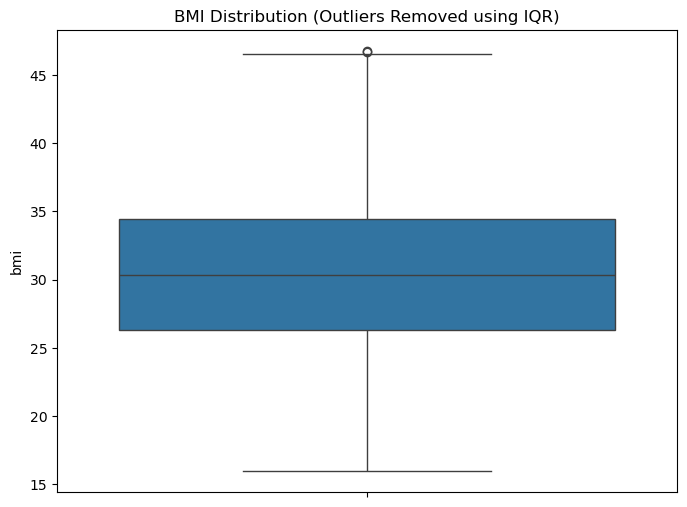

In [7]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

# 2. 상한 및 하한 계산
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"\nQ1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"하한 (Lower Bound): {lower_bound:.2f}")
print(f"상한 (Upper Bound): {upper_bound:.2f}")

# 3. 이상치 제거
# 하한과 상한 사이에 있는 데이터만 선택
df_no_outliers = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]

print(f"\n원본 데이터 행 수: {len(df)}")
print(f"이상치 제거 후 데이터 행 수: {len(df_no_outliers)}")
print("\n이상치 제거 후 BMI 데이터 (head):")
print(df_no_outliers['bmi'].head())

# 이상치 제거 후 BMI 분포 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_no_outliers['bmi'])
plt.title('BMI Distribution (Outliers Removed using IQR)')
plt.show()

In [8]:
X = df_no_outliers.drop('charges', axis = 1)
y = df_no_outliers['charges'].values

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['region'] = le.fit_transform(X['region'])

In [10]:
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker'], dtype=int)

In [11]:
print(X_encoded.head())

   age     bmi  children  region  sex_female  sex_male  smoker_no  smoker_yes
0   19  27.900         0       3           1         0          0           1
1   18  33.770         1       2           0         1          1           0
2   28  33.000         3       2           0         1          1           0
3   33  22.705         0       1           0         1          1           0
4   32  28.880         0       1           0         1          1           0


# 선형회귀 모델

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, 
                 y, 
                 test_size= 0.3, 
                 random_state= 156)
lr = LinearRegression()
lr.fit(X_train ,y_train)
y_pred = lr.predict(X_test)
y_pred[:3]

array([2841.59601289, 9009.23451296, 3816.16908309])

In [13]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(6151.813900479235), np.float64(37844814.26612953))

In [14]:
r2_score(y_test, y_pred)

np.float64(0.7704683203758155)

# 랜덤포레스트 회귀

In [15]:
rd = RandomForestRegressor()
rd.fit(X_train ,y_train)
y_pred1 = rd.predict(X_test)


In [16]:
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)
rmse1, mse1

(np.float64(4661.6325441907065), np.float64(21730817.97705792))

In [17]:
r2_score(y_test, y_pred1)

np.float64(0.8682009346166716)

# 선형회귀 교차검증

In [18]:
# cross_val_score
r2_scores=cross_val_score(lr, X_encoded, y, scoring='r2', cv = 5)
np.mean(r2_scores), r2_scores

(np.float64(0.7453996947836442),
 array([0.76093314, 0.71059896, 0.77030664, 0.72853595, 0.75662378]))

In [19]:
r2_scores=cross_val_score(rd, X_encoded, y, scoring='r2', cv = 5)
np.mean(r2_scores), r2_scores

(np.float64(0.828859575338727),
 array([0.85090679, 0.77090409, 0.84147056, 0.8253963 , 0.85562013]))

In [20]:
neg_mse_scores=cross_val_score(lr, X_encoded, y, scoring='neg_mean_squared_error', cv = 5)
rmse = np.sqrt(neg_mse_scores*-1)
np.mean(rmse),rmse

(np.float64(6035.235125709736),
 array([6117.54613633, 6146.4273525 , 5574.20333149, 6247.462367  ,
        6090.53644123]))

In [21]:
neg_mse_scores=cross_val_score(rd, X_encoded, y, scoring='neg_mean_squared_error', cv = 5)
rmse = np.sqrt(neg_mse_scores*-1)
np.mean(rmse),rmse

(np.float64(4925.143429339074),
 array([4822.7709202 , 5413.14484633, 4585.00897748, 5048.37481332,
        4756.41758936]))

# 다중회귀

In [22]:
results = []

for degree in range(1,5):
    model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False )),
    ('rand', RandomForestRegressor())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,2.239488e+07,4732.323322,0.864173
1,2,2.227827e+07,4719.986351,0.864881
2,3,2.225104e+07,4717.100862,0.865046
3,4,2.231151e+07,4723.506445,0.864679


# 릿지

In [23]:
alphas = [0.001, 0.01, 0.1, 1.0 ,10, 100]
ridge_cv = RidgeCV(alphas=alphas, cv = 5)
ridge_cv.fit(X_train, y_train)
ridge_preds = ridge_cv.predict(X_test)
print("MSE:", mean_squared_error(y_test, ridge_preds))
print("R2:", r2_score(y_test, ridge_preds))

MSE: 37887920.37013109
R2: 0.7702068785734075


In [24]:
ridge_cv.alpha_

np.float64(1.0)

# 라쏘

In [26]:
alphas = [0.001, 0.01, 0.1, 1.0 ,10, 100]
lasso_CV = LassoCV(alphas=alphas, cv = 5)
lasso_CV.fit(X_train, y_train)
lasso_preds = lasso_CV.predict(X_test)
print("MSE:", mean_squared_error(y_test, lasso_preds))
print("R2:", r2_score(y_test, lasso_preds))

MSE: 37860780.40165428
R2: 0.7703714845483668


In [27]:
lasso_CV.alpha_

np.float64(10.0)

# 엘라스틱

In [28]:
alphas = [0.001, 0.01, 0.1, 1.0 ,10, 100]
enet_cv = ElasticNetCV(alphas=alphas, cv = 5)
enet_cv.fit(X_train, y_train)
enet_pred = enet_cv.predict(X_test)
print("MSE:", mean_squared_error(y_test, enet_pred))
print("R2:", r2_score(y_test, enet_pred))

MSE: 37864605.85726783
R2: 0.7703482828688413


In [29]:
enet_cv.alpha_

np.float64(0.001)

# 모델 간 비교

In [30]:
results = pd.DataFrame ({
    'model' : ['poly', 'ridge', 'lasso', 'enet'],
    'mse' : [mean_squared_error(y_test, pred_poly),
             mean_squared_error(y_test, pred_ridge),
             mean_squared_error(y_test, lasso_preds),
             mean_squared_error(y_test, enet_pred)],
    'rmse' : [np.sqrt(mean_squared_error(y_test, pred_poly)),
            np.sqrt(mean_squared_error(y_test, pred_ridge)),
            np.sqrt(mean_squared_error(y_test, lasso_preds)),
            np.sqrt(mean_squared_error(y_test, enet_pred))],
    'r2' : [r2_score(y_test, pred_poly),
             r2_score(y_test, pred_ridge),
             r2_score(y_test, lasso_preds),
             r2_score(y_test, enet_pred)]
    
})

results

,model,mse,rmse,r2
0,poly,2.231151e+07,4723.506445,0.864679
1,ridge,3.788792e+07,6155.316431,0.770207
2,lasso,3.786078e+07,6153.111441,0.770371
3,enet,3.786461e+07,6153.422288,0.770348
